In [2]:
# Importar librerías necesarias
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Cargar el conjunto de datos
iris = load_iris(as_frame=True)
data = iris.data

In [4]:
# Visualizar las estadísticas iniciales
print("Estadísticas iniciales:")
data.describe()

Estadísticas iniciales:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
# Aplicar MinMaxScaler
minmax_scaler = MinMaxScaler()
data_minmax = pd.DataFrame(minmax_scaler.fit_transform(data), columns=data.columns)

In [6]:
# Aplicar StandardScaler
standard_scaler = StandardScaler()
data_standard = pd.DataFrame(standard_scaler.fit_transform(data), columns=data.columns)
print("--- Estadísticas Originales ---")
display(data.describe())

print("\n--- Estadísticas MinMax Scaled ---")
display(data_minmax.describe())

import seaborn as sns

plt.figure(figsize=(12, 5))

--- Estadísticas Originales ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



--- Estadísticas MinMax Scaled ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,0.428704,0.440556,0.467458,0.458056
std,0.230018,0.181611,0.299203,0.317599
min,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.333333,0.101695,0.083333
50%,0.416667,0.416667,0.567797,0.500000
75%,0.583333,0.541667,0.694915,0.708333
max,1.000000,1.000000,1.000000,1.000000


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(0.5, 0, 'Valor original (cm)')

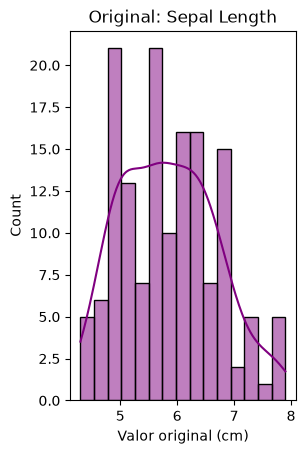

In [7]:
# Distribución original
plt.subplot(1, 2, 1)
sns.histplot(data['sepal length (cm)'], kde=True, color='purple', bins=15)
plt.title('Original: Sepal Length')
plt.xlabel('Valor original (cm)')


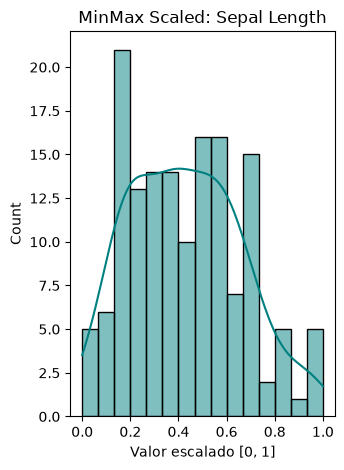

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [8]:
# Distribución con MinMax
plt.subplot(1, 2, 2)
sns.histplot(data_minmax['sepal length (cm)'], kde=True, color='teal', bins=15)
plt.title('MinMax Scaled: Sepal Length')
plt.xlabel('Valor escalado [0, 1]')
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 6))


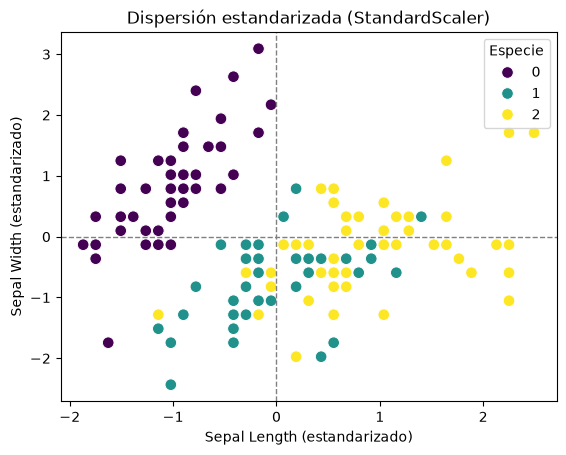

In [9]:
# Gráfico de dispersión con datos estandarizados
sns.scatterplot(
    x=data_standard['sepal length (cm)'], 
    y=data_standard['sepal width (cm)'], 
    hue=iris.target, # Colorear por las especies originales de Iris
    palette='viridis',
    s=70
)

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Dispersión estandarizada (StandardScaler)')
plt.xlabel('Sepal Length (estandarizado)')
plt.ylabel('Sepal Width (estandarizado)')
plt.legend(title='Especie')
plt.show()

In [10]:
'''
¿Qué técnica de escalado crees que es más adecuada para este conjunto de datos? ¿Por qué?
StandardScaler suele ser ligeramente más adecuada o común para el conjunto de datos Iris, especialmente si planeas usar algoritmos basados en distancias (como K-Nearest Neighbors o SVM)
 o análisis de componentes principales (PCA).
Las características de Iris se distribuyen de manera relativamente cercana a una campana de Gauss (distribución normal). StandardScaler maneja muy bien esto al centrar la media en 0 y 
estandarizar la varianza.
A diferencia de MinMaxScaler, el StandardScaler es menos sensible a los valores atípicos (outliers), ya que no comprime estrictamente todos los datos a un rango cerrado fijo, sino que 
los mide en función de cuántas desviaciones estándar están alejados de la media.
'''

'\n¿Qué técnica de escalado crees que es más adecuada para este conjunto de datos? ¿Por qué?\nStandardScaler suele ser ligeramente más adecuada o común para el conjunto de datos Iris, especialmente si planeas usar algoritmos basados en distancias (como K-Nearest Neighbors o SVM)\n o análisis de componentes principales (PCA).\nLas características de Iris se distribuyen de manera relativamente cercana a una campana de Gauss (distribución normal). StandardScaler maneja muy bien esto al centrar la media en 0 y \nestandarizar la varianza.\nA diferencia de MinMaxScaler, el StandardScaler es menos sensible a los valores atípicos (outliers), ya que no comprime estrictamente todos los datos a un rango cerrado fijo, sino que \nlos mide en función de cuántas desviaciones estándar están alejados de la media.\n'